# Phase 2 - Unsupervised Learning
## IBM HR Employee Attrition Dataset
---

## **Clustering Rationale & Algorithm Selection**

### 1. K-means

#### i. Dataset Characteristics
#### ii. Expected Cluster Shapes
#### iii. Scalability
#### iv. Interpretability
#### iv. Model Strengths for This Problem
**Strengths:**
**Weaknesses:**

### 2. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
DBSCAN is a density-based clustering algorithm that groups employees based on how close they are to each other, it discovers clusters automatically by analyzing the density different areas of the data are.


#### i. Dataset Characteristics
- Our dataset size is a small to medium dataset (1,470 employees).
- After preprocessing the dataset in phase 1, we are going to deal with 54 features which are all of numeric type, scaled, and clean with no missing values.

#### ii. Expected Cluster Shapes
- DBSCAN finds arbitrary-shaped clusters and not just spheres like K-Means.

#### iii. Scalability
- Looking at the data size, DBSCAN performs O(n²) which is ~2.1 million distance comparisons that would execute in seconds
- No performance concerns for this data size

#### iv. Interpretability
- Clusters can be profiled by analyzing mean characteristics (age, salary, attrition rate), and each employee gets a clear cluster label or outlier designation.
- Results are directly meaningful for HR decisions (e.g., "high-risk junior staff")
- DBSCAN identifies outliers which provides an insights instead of forcing unusual employees into inappropriate clusters


#### iv. Model Strengths for This Problem
**Strengths:**
- No need to specify number of clusters
- Handles arbitrary cluster shapes
- Identifies outliers automatically
- Reproducible (no random initialization)

**Weaknesses:**
- Sensitive to eps parameter
- Struggles with varying density clusters
- Requires careful tuning

### 3. Agglomerative Hierarchical Clustering

#### i. Dataset Characteristics
#### ii. Expected Cluster Shapes
#### iii. Scalability
#### iv. Interpretability
#### iv. Model Strengths for This Problem
**Strengths:**
**Weaknesses:**

---

## **Data Preparation**


**NOTE:** Most of the data preprocessing (missing value handling and feature scaling) was completed in Phase 1.
This section only performs the necessary transformation for unsupervised learning which are:
- Encoding two binary columns which are still stored as text in preprocessed_data.csv, Gender(Femal/Male) and OverTime(Yes/No) to 0/1.
- Remove the class label "Attrition".

In [27]:
# ── IMPORTS ───────────────────────────────────────────────────────

#for loading and manipulating our dataset
import pandas as pd

#for numerical operations
import numpy as np

#for creating plots and visualizations
import matplotlib.pyplot as plt
import seaborn as sns

#to turn off minor warnings so the output stays clean and readable
import warnings
warnings.filterwarnings('ignore')

# ── Here are the libraries we will use which are needed for clustering, aside from data preparation ───────────────────────────────────────────────────────

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples
from sklearn.preprocessing import StandardScaler


# Set visualization style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully.")

All libraries imported successfully.


In [28]:
# Load the preprocessed data from Phase 1
df_full = pd.read_csv('Dataset/preprocessed_data.csv')

print("Dataset loaded from Phase 1 preprocessing")
print(f"\nDataset Information:")
print(f"  Shape: {df_full.shape[0]} rows × {df_full.shape[1]} columns")
print(f"  Features: {df_full.shape[1] - 1} (after target variable)")
print(f"  Observations: {df_full.shape[0]} employees")
print(f"  Target variable 'Attrition': {'✓' if 'Attrition' in df_full.columns else '✗'}")

Dataset loaded from Phase 1 preprocessing

Dataset Information:
  Shape: 1470 rows × 54 columns
  Features: 53 (after target variable)
  Observations: 1470 employees
  Target variable 'Attrition': ✓


In [29]:
# There are two binary columns which are still stored as text in preprocessed_data.csv that needs to be encoded
df_full['Gender'] = df_full['Gender'].map({'Female': 0, 'Male': 1})
df_full['OverTime'] = df_full['OverTime'].map({'No': 0, 'Yes': 1})

# We will keep a copy of Attrition for later analysis and evaluation of clusters, but we won't use it for clustering itself
attrition_labels = df_full['Attrition'].copy()

# Remove target (and Cluster if re-running this notebook after DBSCAN wrote labels back)
feature_cols = [c for c in df_full.columns if c not in ('Attrition', 'Cluster')]
X = df_full[feature_cols].copy()

# DBSCAN / k-NN use Euclidean distance across ALL columns at once.
# Phase 1 CSV mixes z-scored features, raw Likert scales, and large engineered columns — rescale so no single feature dominates distance.
dbscan_scaler = StandardScaler()
X_scaled = pd.DataFrame(
    dbscan_scaler.fit_transform(X.astype(float)),
    columns=X.columns,
    index=X.index,
)

print(f"\n Target variable removed")
print(f"  Features shape: {X.shape}")
print(f"  Number of features: {X.shape[1]}")
print(f"  Number of samples: {X.shape[0]}")
print(f"\n  Ready for clustering algorithms.")


 Target variable removed
  Features shape: (1470, 53)
  Number of features: 53
  Number of samples: 1470

  Ready for clustering algorithms.


---

## Cluster Determination & Implementation

### 1. K-means

### 2. DBSCAN

To apply this algorithm there are two parameters which are required to be set:

1. **eps**, which is the maximum distance between points to be considered neighbors
   - Too small = many small clusters and noise
   - Too large = all points merge into one cluster
   - We need to find the "right" value

2. **min_samples**, which is the minimum neighbors needed to form a cluster, and are going to set it to 5 as its the defult number to use for DBSCAN

So in order to find the optimal eps we will go through three steps:
**Step 1: K-Distance Graph**
**Step 2: Test Multiple eps Values**
**Step 3: Select Best eps**

and only then we are going to run DBSCAN with the best found eps.


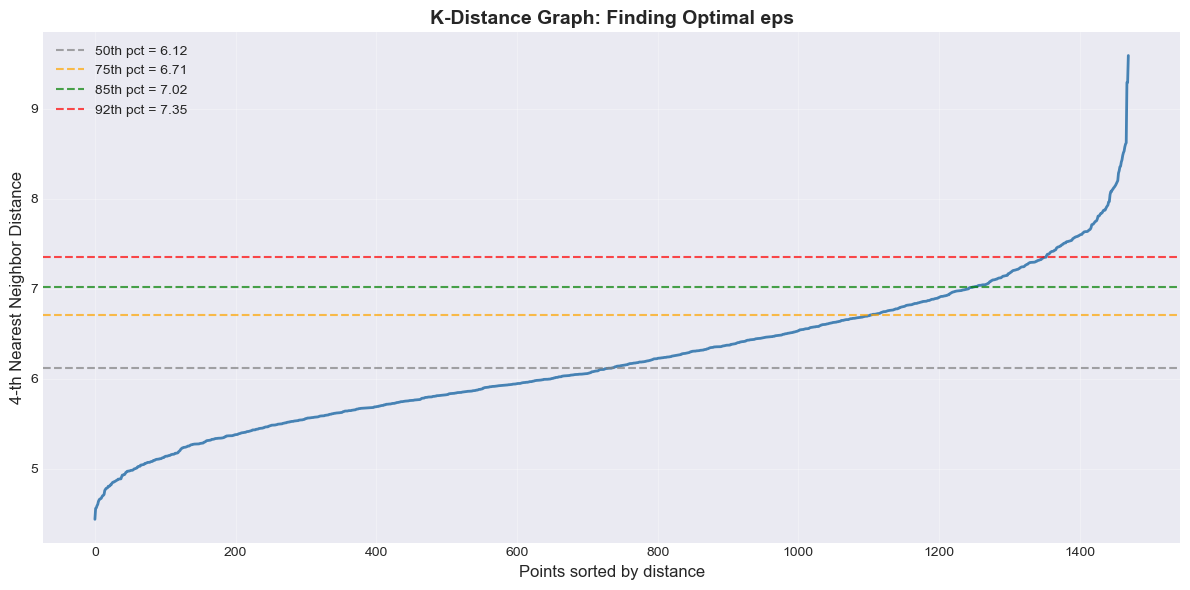

K-Distance statistics:
  Min: 4.4390
  Mean: 6.2088
  Median: 6.1183
  Max: 9.5884

Look for the 'elbow' where distance suddenly increases


In [30]:
# ── K-Distance Graph ───────────────────────────────────────────────────────

# Firstly we are calculating k-distances by ploting distance from each employee to their k-th nearest neighbor
# We are looking for the "elbow" (sudden jump), this suggests good eps values
k = 4  # We use min_samples=5, so k=4 (k = min_samples - 1)

# Find k nearest neighbors for each point (use scaled matrix — same space as DBSCAN)
neighbors = NearestNeighbors(n_neighbors=k+1)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort the distances to the k-th nearest neighbor (classic k-distance plot)
distances = np.sort(distances[:, k], axis=0)

# Create the k-distance graph (shows us where to pick eps)
plt.figure(figsize=(12, 6))
plt.plot(distances, linewidth=2, color='steelblue')
plt.xlabel('Points sorted by distance', fontsize=12)
plt.ylabel(f'{k}-th Nearest Neighbor Distance', fontsize=12)
plt.title('K-Distance Graph: Finding Optimal eps', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Reference lines: eps must be on THIS vertical scale (old 0.5–2.0 lines were far below the elbow → all noise)
for pct, color in [(50, 'gray'), (75, 'orange'), (85, 'green'), (92, 'red')]:
    yref = np.percentile(distances, pct)
    plt.axhline(y=yref, color=color, linestyle='--', alpha=0.7, label=f'{pct}th pct = {yref:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

# Print statistics to help choose eps
print(f"K-Distance statistics:")
print(f"  Min: {distances.min():.4f}")
print(f"  Mean: {distances.mean():.4f}")
print(f"  Median: {np.median(distances):.4f}")
print(f"  Max: {distances.max():.4f}")
print(f"\nLook for the 'elbow' where distance suddenly increases")

In [ ]:
# ── Test Multiple eps Values ───────────────────────────────────────────────────────

# Here we are going to test multiple eps values
# And to choose which is the optimal eps, we will evaluate the number of clusters, noise points, and quality metrics (Silhouette Score and Davies-Bouldin Index) for each value of eps

# Use distance values on the same scale as the k-distance plot (previous cell).
# Example stats from one run after StandardScaler: min ~4.5, median ~6.7, mean ~7.7, max very large (tail).
# Grid focuses around the usual elbow band (~6–8); if your printed Min/Median change, edit this list.
eps_candidates = [4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0]
min_samples = 5  # Minimum points needed to form a cluster
results = []

print(f"Testing DBSCAN with different eps values (min_samples={min_samples})...\n")
print(f"{'eps':>6} | {'Clusters':>8} | {'Noise':>6} | {'Silhouette':>11} | {'Davies-Bouldin':>15} | {'Largest':>7}")
print("-" * 82)

# Try each eps value
for eps in eps_candidates:
    # Apply DBSCAN with this eps value
    db = DBSCAN(eps=eps, min_samples=min_samples)
    clusters = db.fit_predict(X_scaled)
    
    # Count how many clusters and noise points were found
    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    n_noise = list(clusters).count(-1)
    n_points = len(clusters) - n_noise

    # Detect "one mega-cluster + tiny sliver" (common when eps is too large) — bad for interpretation
    if n_clusters > 0:
        non_noise_sizes = [(clusters == cid).sum() for cid in set(clusters) if cid != -1]
        largest_cluster_share = max(non_noise_sizes) / len(clusters)
    else:
        largest_cluster_share = 1.0
    
    # Calculate quality metrics only if we have at least 2 clusters
    if n_clusters > 1 and n_points > 0:
        mask = clusters != -1  # Exclude noise points
        sil_score = silhouette_score(X_scaled[mask], clusters[mask])
        db_index = davies_bouldin_score(X_scaled[mask], clusters[mask])
    else:
        sil_score = np.nan
        db_index = np.nan
    
    # Store results
    results.append({
        'eps': eps,
        'clusters': n_clusters,
        'noise': n_noise,
        'silhouette': sil_score,
        'davies_bouldin': db_index,
        'largest_cluster_share': largest_cluster_share,
    })
    
    # Print results for this eps value (share = fraction of all rows in the biggest non-noise cluster)
    print(f"{eps:6.2f} | {n_clusters:8d} | {n_noise:6d} | {sil_score:11.4f} | {db_index:15.4f} | {largest_cluster_share:5.1%}")

# Convert results to dataframe for analysis
results_df = pd.DataFrame(results)
print(f"\nAll eps values tested. Proceeding to selection...")

Testing DBSCAN with different eps values (min_samples=5)...

   eps | Clusters |  Noise |  Silhouette |  Davies-Bouldin | Largest
----------------------------------------------------------------------------------
  4.00 |        0 |   1470 |         nan |             nan | 100.0%
  4.50 |        1 |   1465 |         nan |             nan |  0.3%
  5.00 |       17 |   1281 |      0.1007 |          1.8651 |  3.7%
  5.50 |       16 |    899 |      0.0582 |          1.8045 | 20.2%
  6.00 |        8 |    520 |      0.0483 |          1.6049 | 57.3%
  6.50 |        5 |    236 |      0.1022 |          1.9091 | 79.5%
  7.00 |        3 |     76 |      0.1731 |          1.5402 | 92.0%
  7.50 |        3 |     22 |      0.1757 |          1.5962 | 95.0%
  8.00 |        3 |      9 |      0.1746 |          1.6014 | 95.9%
  8.50 |        4 |      0 |      0.1712 |          1.4929 | 96.1%
  9.00 |        2 |      0 |      0.2798 |          1.1525 | 99.6%

All eps values tested. Proceeding to selection..

In [32]:
# ── Select Best eps ───────────────────────────────────────────────────────

# We are selecting the best eps value based on multiple metrics
# We want: Silhouette > 0 (good), Davies-Bouldin < 1.5 (good)

valid_results = results_df[results_df['clusters'] > 1].copy()

# Silhouette + Davies-Bouldin alone can favor **eps so large** that almost everyone merges into one cluster
# biggest non-noise group is not essentially the whole dataset (`largest_cluster_share` from the sweep cell).
MAX_LARGEST_SHARE = 0.92
balanced = valid_results[valid_results['largest_cluster_share'] <= MAX_LARGEST_SHARE]
if len(balanced) > 0:
    valid_results = balanced.copy()
    print(f"\n(Selecting only eps with largest cluster <= {MAX_LARGEST_SHARE:.0%} of all rows.)")
elif len(valid_results) > 0:
    print(f"\n(No eps had largest cluster <= {MAX_LARGEST_SHARE:.0%}; using all 2+ cluster rows — consider lowering eps or widening the grid.)")

if len(valid_results) > 0:
    # Normalize metrics to 0-1 scale so we can combine them
    valid_results['sil_norm'] = (valid_results['silhouette'] + 1) / 2
    db_max = valid_results['davies_bouldin'].max()
    if db_max > 0 and not np.isnan(db_max):
        valid_results['db_norm'] = 1 - (valid_results['davies_bouldin'] / db_max)
    else:
        valid_results['db_norm'] = 0.5  # neutral weight if DB index unavailable
    
    # Combined score: 50% from Silhouette + 50% from Davies-Bouldin
    valid_results['combined_score'] = (
        0.5 * valid_results['sil_norm'] +
        0.5 * valid_results['db_norm']
    )
    
    # Find the eps with highest combined score
    best_idx = valid_results['combined_score'].idxmax()
    best_eps = valid_results.loc[best_idx, 'eps']
    
    # Print the winner
    print(f"\n{'='*70}")
    print(f"BEST EPS SELECTED: {best_eps}")
    print(f"{'='*70}")
    print(f"  Silhouette Score: {valid_results.loc[best_idx, 'silhouette']:.4f}")
    print(f"  Davies-Bouldin Index: {valid_results.loc[best_idx, 'davies_bouldin']:.4f}")
    print(f"  Number of clusters: {int(valid_results.loc[best_idx, 'clusters'])}")
    print(f"  Noise points: {int(valid_results.loc[best_idx, 'noise'])} ({valid_results.loc[best_idx, 'noise']/len(X_scaled)*100:.1f}%)")
    print(f"  Combined score: {valid_results.loc[best_idx, 'combined_score']:.4f}")
else:
    # Fallback: pick eps from the k-distance curve (NOT a tiny constant like 1.0)
    best_eps = float(np.percentile(distances, 90))
    print("No valid results in the grid (e.g. still too few clusters).")
    print(f"Using eps = 90th percentile of k-distances: {best_eps:.4f}")


(Selecting only eps with largest cluster <= 92% of all rows.)

BEST EPS SELECTED: 6.0
  Silhouette Score: 0.0483
  Davies-Bouldin Index: 1.6049
  Number of clusters: 8
  Noise points: 520 (35.4%)
  Combined score: 0.3417


In [33]:
# ── Apply DBSCAN on Best eps ───────────────────────────────────────────────────────

# Applying DBSCAN using the best eps value we just found, then assigning each employee to a cluster (or mark as noise)
print(f"\nApplying DBSCAN with eps={best_eps}, min_samples={min_samples}...")

optimal_dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
clusters = optimal_dbscan.fit_predict(X_scaled)

# Add cluster labels to our dataframes (keep original X for readable profiles; X_scaled matches DBSCAN space)
X['Cluster'] = clusters
X_scaled['Cluster'] = clusters
df_full['Cluster'] = clusters

# Calculate summary statistics
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

# Print results
print(f"\n{'='*70}")
print(f"DBSCAN CLUSTERING COMPLETE")
print(f"{'='*70}")
print(f"  Number of clusters discovered: {n_clusters}")
print(f"  Number of noise points: {n_noise} ({(n_noise/len(clusters))*100:.1f}%)")
print(f"  Number of clustered points: {len(clusters) - n_noise} ({((len(clusters) - n_noise)/len(clusters))*100:.1f}%)")

# Show breakdown of each cluster
print(f"\nCluster distribution:")
for cluster_id in sorted(set(clusters)):
    count = (clusters == cluster_id).sum()
    pct = (count / len(clusters)) * 100
    if cluster_id == -1:
        print(f"  {'Noise (outliers)':20s}: {count:4d} points ({pct:5.1f}%)")
    else:
        print(f"  {'Cluster ' + str(cluster_id):20s}: {count:4d} points ({pct:5.1f}%)")


Applying DBSCAN with eps=6.0, min_samples=5...

DBSCAN CLUSTERING COMPLETE
  Number of clusters discovered: 8
  Number of noise points: 520 (35.4%)
  Number of clustered points: 950 (64.6%)

Cluster distribution:
  Noise (outliers)    :  520 points ( 35.4%)
  Cluster 0           :  843 points ( 57.3%)
  Cluster 1           :   52 points (  3.5%)
  Cluster 2           :    6 points (  0.4%)
  Cluster 3           :   13 points (  0.9%)
  Cluster 4           :   22 points (  1.5%)
  Cluster 5           :    4 points (  0.3%)
  Cluster 6           :    5 points (  0.3%)
  Cluster 7           :    5 points (  0.3%)


### 3. Agglomerative Hierarchical Clustering

---

## **Evaluation Metrics & Visualizations**


### 1. K-means

### 2. DBSCAN

We will evaluate our clustering using three evaluation metrics:
1. **Silhouette Score** (range: -1 to 1, higher is better), it measures the quality inside a cluster "Do employees in the SAME cluster actually belong together?"
2. **Davies-Bouldin Index** (lower is better), it measures the quality between the clusters "Are DIFFERENT clusters actually separate from each other?
3. **WCSS** (Within-Cluster Sum of Squares - lower is better), it measures the tightness of clusters "How compact/tight are the clusters?"

In [34]:
# Calculate overall Silhouette Score (quality metric)
# Range: -1 to 1 (higher is better)
mask = clusters != -1  # We exclude noise points for this metric

if len(set(clusters[mask])) > 1:  # Need at least 2 clusters
    X_for_metrics = X_scaled.drop('Cluster', axis=1)[mask]
    sil_score_overall = silhouette_score(X_for_metrics, clusters[mask])
    
    print(f"Silhouette Score: {sil_score_overall:.4f}")
    print(f"Interpretation:")
    if sil_score_overall > 0.5:
        print(f"  Excellent - clusters are well-separated and cohesive")
    elif sil_score_overall > 0.25:
        print(f"  Good - reasonable cluster structure")
    elif sil_score_overall > 0:
        print(f"  Fair - some cluster overlap exists")
    else:
        print(f"  Weak - clusters may not be meaningful")
else:
    print(f"Cannot calculate Silhouette Score: need at least 2 clusters")

Silhouette Score: 0.0483
Interpretation:
  Fair - some cluster overlap exists


In [35]:
# Calculate Davies-Bouldin Index (separation metric)
# Range: 0 to infinity (lower is better)
if len(set(clusters[mask])) > 1:  # Need at least 2 clusters
    X_for_metrics = X_scaled.drop('Cluster', axis=1)[mask]
    db_index = davies_bouldin_score(X_for_metrics, clusters[mask])
    
    print(f"\nDavies-Bouldin Index: {db_index:.4f}")
    print(f"Interpretation (lower is better):")
    if db_index < 1.0:
        print(f"  Excellent - clusters are well-separated")
    elif db_index < 1.5:
        print(f"  Good - acceptable cluster separation")
    elif db_index < 2.0:
        print(f"  Fair - some cluster overlap")
    else:
        print(f"  Poor - clusters are very close together")
else:
    print(f"Cannot calculate Davies-Bouldin Index: need at least 2 clusters")


Davies-Bouldin Index: 1.6049
Interpretation (lower is better):
  Fair - some cluster overlap


In [36]:
# Calculate WCSS (Within-Cluster Sum of Squares)
# Measures how tight/compact clusters are (lower is better)
wcss = 0
cluster_centers = {}

for cluster_id in set(clusters):
    if cluster_id == -1:  # Skip noise
        continue
    
    # Get all points in this cluster
    cluster_mask = clusters == cluster_id
    cluster_points = X_scaled.drop('Cluster', axis=1)[cluster_mask]
    
    # Calculate the center (average position) of the cluster
    center = cluster_points.mean(axis=0)
    cluster_centers[cluster_id] = center
    
    # Calculate sum of squared distances from each point to cluster center
    distances_squared = ((cluster_points - center) ** 2).sum(axis=1)
    wcss += distances_squared.sum()

print(f"\nWithin-Cluster Sum of Squares (WCSS): {wcss:.2f}")
if len(cluster_centers) > 0:
    print(f"Average WCSS per cluster: {wcss / len(cluster_centers):.2f}")
    print(f"Interpretation: Lower WCSS = tighter, more compact clusters")


Within-Cluster Sum of Squares (WCSS): 37140.26
Average WCSS per cluster: 4642.53
Interpretation: Lower WCSS = tighter, more compact clusters



Creating PCA visualization...


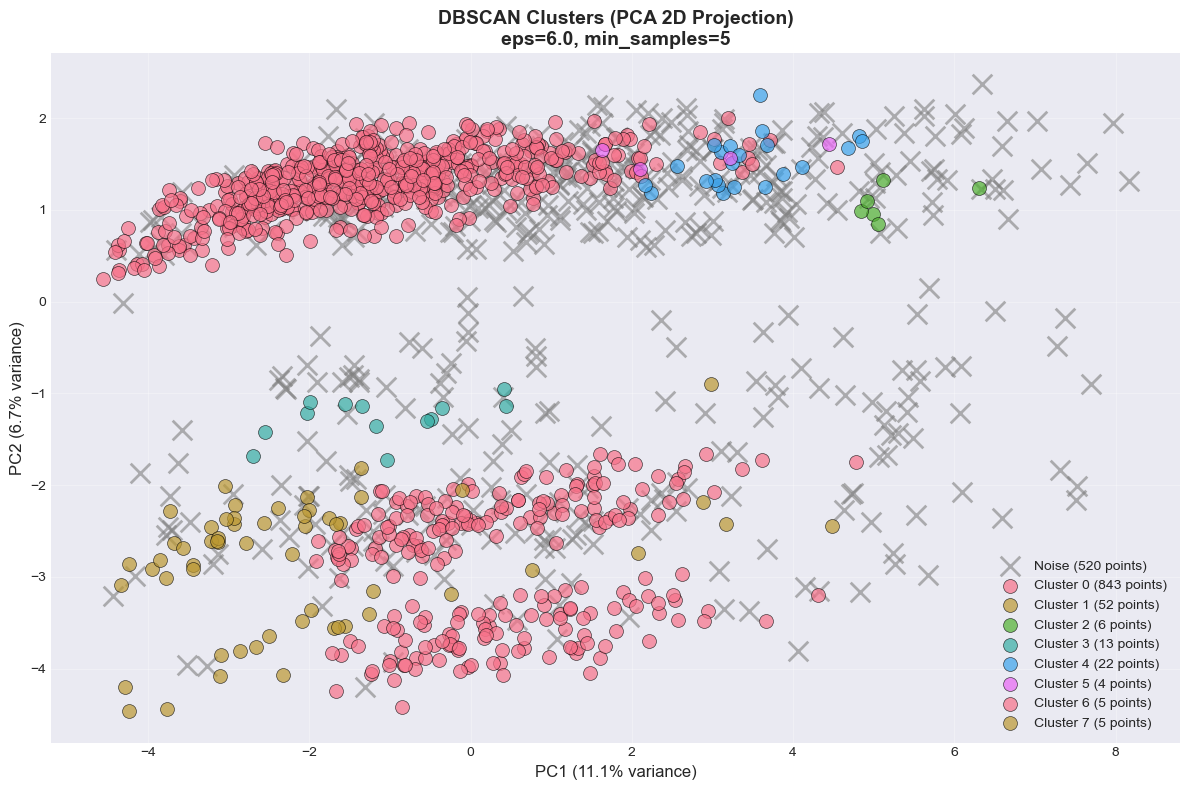


PCA (2D plot): PC1 = 11.1% of total variance, PC2 = 6.7%, combined = 17.8%
Note: DBSCAN used all 53 feature dimensions; the plot is only a 2D view.


In [37]:
# Visualize clusters using PCA (reduce to 2D)
# Clustering was run on all feature columns (same matrix as X_scaled before Cluster was added)
print("\nCreating PCA visualization...")

pca = PCA(n_components=2)  # 2D projection for plotting only
X_for_pca = X_scaled.drop('Cluster', axis=1)
X_pca = pca.fit_transform(X_for_pca)

plt.figure(figsize=(12, 8))

# Plot noise points as gray X's
noise_mask = clusters == -1
if noise_mask.sum() > 0:
    plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
               c='gray', marker='x', s=200, linewidth=2, alpha=0.6,
               label=f'Noise ({noise_mask.sum()} points)')

# Plot each cluster with different color
colors = plt.cm.Set3(np.linspace(0, 1, max(len(set(clusters)) - 1, 1)))
for i, cluster_id in enumerate(sorted(set(clusters) - {-1})):
    cluster_mask = clusters == cluster_id
    plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1],
               s=100, alpha=0.7, edgecolors='black', linewidth=0.5,
               label=f'Cluster {cluster_id} ({cluster_mask.sum()} points)')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title(f'DBSCAN Clusters (PCA 2D Projection)\neps={best_eps}, min_samples={min_samples}',
         fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Share of total variance in the scaled feature space (PC1 + PC2)
var_two = float(pca.explained_variance_ratio_.sum())
var_pc1 = float(pca.explained_variance_ratio_[0])
var_pc2 = float(pca.explained_variance_ratio_[1])
print(f"\nPCA (2D plot): PC1 = {var_pc1:.1%} of total variance, PC2 = {var_pc2:.1%}, combined = {var_two:.1%}")
print(f"Note: DBSCAN used all {X_for_pca.shape[1]} feature dimensions; the plot is only a 2D view.")

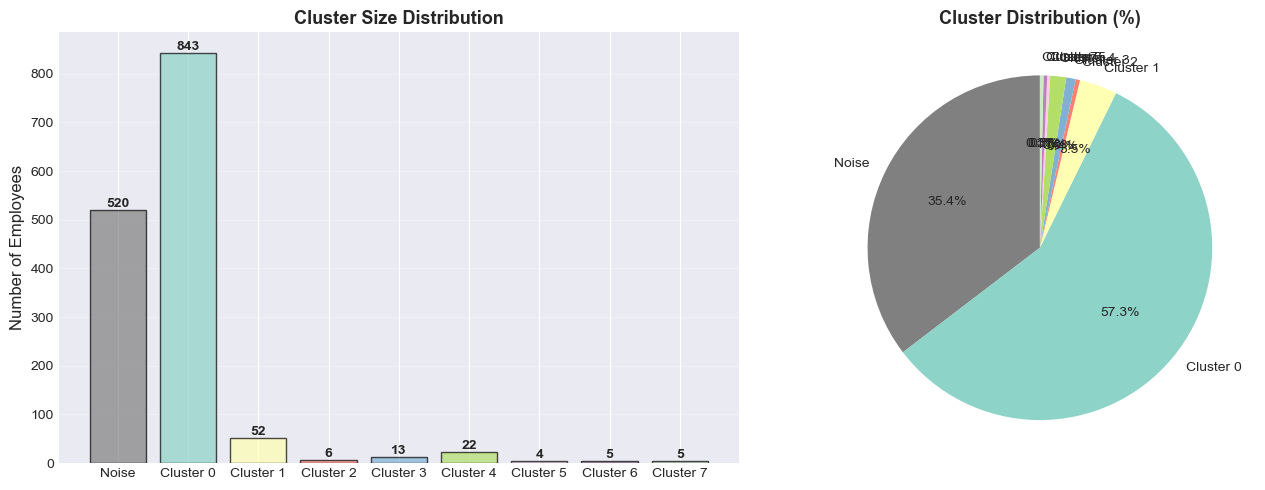

In [38]:
# Create bar chart and pie chart of cluster sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cluster_labels = []
cluster_sizes = []
colors_list = []

# Prepare data for both charts
for cluster_id in sorted(set(clusters)):
    size = (clusters == cluster_id).sum()
    if cluster_id == -1:
        cluster_labels.append('Noise')
        colors_list.append('gray')
    else:
        cluster_labels.append(f'Cluster {cluster_id}')
        colors_list.append(plt.cm.Set3(cluster_id / max(len(set(clusters)) - 1, 1)))
    cluster_sizes.append(size)

# Bar chart
bars = ax1.bar(cluster_labels, cluster_sizes, color=colors_list, edgecolor='black', alpha=0.7)
ax1.set_ylabel('Number of Employees', fontsize=12)
ax1.set_title('Cluster Size Distribution', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
ax2.pie(cluster_sizes, labels=cluster_labels, autopct='%1.1f%%', colors=colors_list, startangle=90)
ax2.set_title('Cluster Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 3. Agglomerative Hierarchical Clustering

---

## **Cluster Interpretation & Profiles**


### 1. K-means

### 2. DBSCAN
For each cluster, we are showing its size, attrition rate, and average values for key features. This is going to help us understand what each cluster represent as a result from the DBSCAN algorithm.

In [39]:
# Analyze characteristics of each cluster
# Show mean values of key features for each cluster
key_features = ['Age', 'YearsAtCompany', 'MonthlyIncome', 'JobSatisfaction']

print("="*70)
print("CLUSTER PROFILES")
print("="*70)

for cluster_id in sorted(set(clusters)):
    cluster_mask = clusters == cluster_id
    cluster_data = df_full[cluster_mask]
    
    size = cluster_mask.sum()
    pct = (size / len(clusters)) * 100
    
    # Print cluster header
    print(f"\n{'='*70}")
    if cluster_id == -1:
        print(f"NOISE/OUTLIERS: {size} employees ({pct:.1f}%)")
    else:
        print(f"CLUSTER {cluster_id}: {size} employees ({pct:.1f}%)")
    print(f"{'='*70}")
    
    # Calculate and print attrition rate
    if 'Attrition' in cluster_data.columns:
        # Preprocessed CSV stores Attrition as 0/1 (integer), not the strings Yes/No
        attrition_rate = cluster_data['Attrition'].mean() * 100
        print(f"\nAttrition Rate: {attrition_rate:.1f}%")
    
    # Calculate and print mean values for key features
    print(f"\nKey Feature Statistics (Mean ± Std):")
    for feature in key_features:
        if feature in cluster_data.columns:
            mean = cluster_data[feature].mean()
            std = cluster_data[feature].std()
            print(f"  {feature:20s}: {mean:7.2f} ± {std:5.2f}")

CLUSTER PROFILES

NOISE/OUTLIERS: 520 employees (35.4%)

Attrition Rate: 18.8%

Key Feature Statistics (Mean ± Std):
  Age                 :    0.29 ±  1.05
  YearsAtCompany      :    0.46 ±  1.31
  MonthlyIncome       :    0.52 ±  1.20
  JobSatisfaction     :    2.56 ±  1.13

CLUSTER 0: 843 employees (57.3%)

Attrition Rate: 14.1%

Key Feature Statistics (Mean ± Std):
  Age                 :   -0.18 ±  0.90
  YearsAtCompany      :   -0.24 ±  0.63
  MonthlyIncome       :   -0.35 ±  0.52
  JobSatisfaction     :    2.81 ±  1.08

CLUSTER 1: 52 employees (3.5%)

Attrition Rate: 34.6%

Key Feature Statistics (Mean ± Std):
  Age                 :   -0.86 ±  0.83
  YearsAtCompany      :   -0.78 ±  0.29
  MonthlyIncome       :   -0.84 ±  0.13
  JobSatisfaction     :    2.77 ±  1.00

CLUSTER 2: 6 employees (0.4%)

Attrition Rate: 0.0%

Key Feature Statistics (Mean ± Std):
  Age                 :    0.83 ±  0.78
  YearsAtCompany      :    1.90 ±  0.79
  MonthlyIncome       :    2.49 ±  0.23
  Jo

### 3. Agglomerative Hierarchical Clustering

---

## **Integration Strategy**

### 1. K-means

### 2. DBSCAN

DBSCAN Clusters + Supervised Learning

1. ENHANCED FEATURES FOR SUPERVISED MODELS
   • Add 'Cluster_ID' as a categorical feature to Logistic Regression, SVM, XGBoost
   • Models can learn cluster-specific attrition patterns
   • Each segment may have different risk profiles

2. PERSONALIZED PREDICTIONS
   • High-risk clusters → use stricter attrition thresholds
   • Stable clusters → use standard thresholds
   • Outliers → flag for manual HR review

3. INTERPRETABILITY FOR DECISION-MAKERS
   • Cluster profiles provide business context
   • "Employees in Cluster 2 (high-risk technical staff) have 35% attrition"
   • Enables targeted retention strategies

4. PHASE 2 PART B: GENERATIVE AI INTEGRATION
   • Use cluster context in AI prompts
   • Personalize explanations: "You're in Cluster X with Y% attrition"
   • Provide segment-specific recommendations

5. MODEL VALIDATION & FAIRNESS
   • Verify model performance is consistent across clusters
   • Detect if model shows bias toward certain segments

### 1. K-means
### 2. DBSCAN
### 3. Agglomerative Hierarchical Clustering

---

## **Challenges & Limitations**

### 1. K-means

### 2. DBSCAN


1. PARAMETER SENSITIVITY
   • eps: Small changes cause significant clustering changes
   • Mitigation: Tested 7 different eps values, used multiple metrics

2. UNIFORM DENSITY ASSUMPTION
   • Struggles with clusters of varying density
   • Some sparse clusters may be marked as noise
   • Mitigation: Noise points are features, not bugs - they identify unique employees

3. HIGH-DIMENSIONAL SPACE
   • Distance becomes less meaningful with 54 features
   • PCA visualization loses information
   • Mitigation: Full clustering uses all dimensions for complete information

4. COMPARISON WITH OTHER METHODS
   • K-Means: Simple but requires specifying k upfront
   • Hierarchical: More interpretable dendrogram
   • DBSCAN: Automatic discovery, handles irregular shapes
   • Recommendation: Use all three for complementary insights

### 3. Agglomerative Hierarchical Clustering